In [1]:
!pip install pykan
!pip install matplotlib numpy torch scikit-learn sympy

Defaulting to user installation because normal site-packages is not writeable
  Using cached pykan-0.2.8-py3-none-any.whl.metadata (11 kB)
Using cached pykan-0.2.8-py3-none-any.whl (78 kB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.3 MB 13.3 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 13.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 12.3 MB/s  0:00:00
   ------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from kan import *
import sympy

# Configuración de semilla para reproducibilidad 
torch.manual_seed(42)
np.random.seed(42)

In [9]:
# Definimos la función objetivo
f = lambda x: torch.exp(torch.sin(torch.pi * x[:, [0]]) + x[:, [1]]**2)

# Creamos el dataset usando create_dataset de pykan
# n_var=2 (x, y)
# train_num=1000 puntos
dataset = create_dataset(f, n_var=2, train_num=1000, test_num=1000)

# Visualizamos los datos
print(f"Entrada (train): {dataset['train_input'].shape}")
print(f"Etiqueta (train): {dataset['train_label'].shape}")

Entrada (train): torch.Size([1000, 2])
Etiqueta (train): torch.Size([1000, 1])


checkpoint directory created: ./model
saving model version 0.0
KAN Inicializada (Aleatoria)


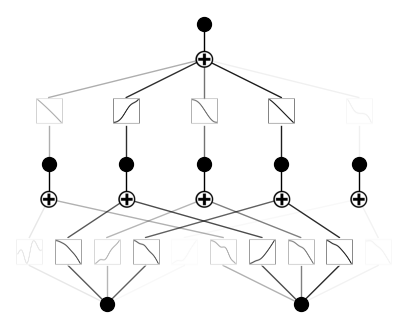

In [12]:
# Inicializamos el modelo
# grid=5 es bajo, ideal para entrenamiento rápido inicial
# k=3 para suavidad (C2)
model = KAN(width=[2, 5, 1], grid=5, k=3, seed=42)

# Visualización inicial (antes de entrenar)
# Las líneas son splines aleatorios
model(dataset['train_input'])

print("KAN Inicializada (Aleatoria)")
model.plot()
plt.show()

In [13]:
# Entrenamos el modelo
# opt="LBFGS" es clave para alta precisión en KANs
# steps=20 es suficiente para este problema simple con LBFGS
results = model.fit(dataset, opt="LBFGS", steps=20, lamb=0.01, lamb_entropy=10.0)

print(f"Loss final de entrenamiento: {results['train_loss'][-1]:.4e}")
print(f"Loss final de test: {results['test_loss'][-1]:.4e}")

| train_loss: 5.05e-02 | test_loss: 4.72e-02 | reg: 1.73e+01 | : 100%|█| 20/20 [00:15<00:00,  1.27it

saving model version 0.1
Loss final de entrenamiento: 5.0530e-02
Loss final de test: 4.7174e-02


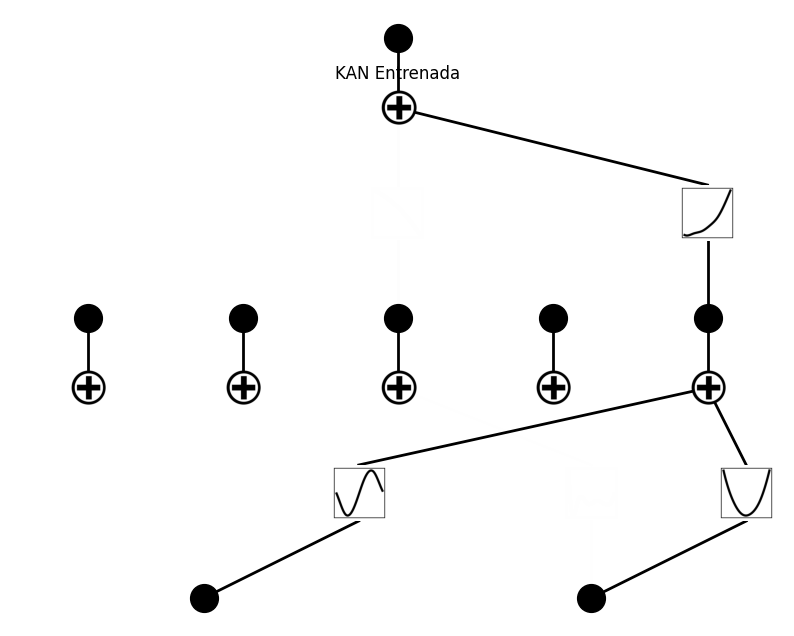

In [14]:
# Graficamos la red entrenada
# beta controla la transparencia. Con beta alto, las conexiones débiles desaparecen visualmente.
model.plot(beta=100, scale=1.0)
plt.title("KAN Entrenada")
plt.show()

saving model version 0.4
KAN Podada (Estructura descubierta)


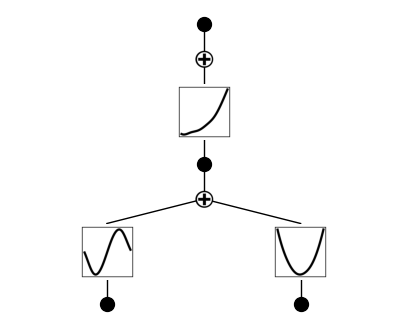

Nueva forma de la red: [[2, 0], [1, 0], [1, 0]]


In [17]:
# Podamos la red automáticamente con un umbral
# Esto elimina nodos inactivos
model = model.prune(node_th=1e-2, edge_th=1e-2)

print("KAN Podada (Estructura descubierta)")
# Visualizamos la red podada
model.plot(beta=100)
plt.show()

# Verificamos la nueva arquitectura
print(f"Nueva forma de la red: {model.width}")
# Debería ser idealmente [2, 1, 1] o [2, 2, 1] dependiendo de la semilla

In [23]:
SYMBOLIC_LIB.keys()


dict_keys(['x', 'x^2', 'x^3', 'x^4', 'x^5', '1/x', '1/x^2', '1/x^3', '1/x^4', '1/x^5', 'sqrt', 'x^0.5', 'x^1.5', '1/sqrt(x)', '1/x^0.5', 'exp', 'log', 'abs', 'sin', 'cos', 'tan', 'tanh', 'sgn', 'arcsin', 'arccos', 'arctan', 'arctanh', '0', 'gaussian'])

In [30]:
import torch
from kan import KAN
from kan.utils import create_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Definir la función objetivo
def f(x: torch.Tensor) -> torch.Tensor:
    # x: (N, 2)
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    # Mezcla de funciones "especiales" para que tenga sentido usar simbólico
    y = torch.sin(x1) + torch.exp(x2) + 0.5 * x1**2
    return y

# 2) Crear dataset sintético
dataset = create_dataset(
    f,
    n_var=2,
    train_num=2000,
    test_num=200,
    device=device,
)

# 3) Definir y entrenar el modelo
model = KAN(width=[2, 5, 1], grid=3, k=3, seed=2, device=device)
model.fit(dataset, opt="LBFGS", steps=20)
model = model.refine(20)
model.fit(dataset, opt="LBFGS", steps=20)

# 4) Activar simbólico y hacer un forward para guardar activaciones
model.symbolic_enabled = True
model.save_act = True
with torch.no_grad():
    _ = model(dataset["train_input"])

# 5) Probar suggest_symbolic en un enlace concreto
name, fun, r2, c = model.suggest_symbolic(0, 0, 0)
print("Mejor función:", name, "R2:", r2)

# 6) Reajustar coeficientes afines sin mover el grid
model.fit(dataset, opt="LBFGS", steps=20, update_grid=False)


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.30e-03 | test_loss: 1.26e-03 | reg: 1.39e+01 | : 100%|█| 20/20 [00:24<00:00,  1.23s/


saving model version 0.1
saving model version 0.2


| train_loss: 1.94e-04 | test_loss: 1.90e-04 | reg: 1.40e+01 | : 100%|█| 20/20 [00:34<00:00,  1.73s/


saving model version 0.3
   function  fitting r2    r2 loss  complexity  complexity loss  total loss
0       sin    0.999906 -13.236147           2                2   -1.047229
1       cos    0.999906 -13.236147           2                2   -1.047229
2  gaussian    0.999935 -13.704493           3                3   -0.340899
3         0    0.000000   0.000014           0                0    0.000003
4         x    0.838679  -2.631902           1                1    0.273620
Mejor función: sin R2: 0.9999063611030579


| train_loss: 9.84e-05 | test_loss: 9.12e-05 | reg: 1.40e+01 | : 100%|█| 20/20 [00:24<00:00,  1.24s/

saving model version 0.4


{'train_loss': [array(0.00018681, dtype=float32),
  array(0.0001827, dtype=float32),
  array(0.00017577, dtype=float32),
  array(0.00016225, dtype=float32),
  array(0.00015265, dtype=float32),
  array(0.00014364, dtype=float32),
  array(0.00013828, dtype=float32),
  array(0.00013292, dtype=float32),
  array(0.0001261, dtype=float32),
  array(0.00012123, dtype=float32),
  array(0.00011725, dtype=float32),
  array(0.00011383, dtype=float32),
  array(0.00011067, dtype=float32),
  array(0.00010736, dtype=float32),
  array(0.00010465, dtype=float32),
  array(0.00010304, dtype=float32),
  array(0.00010162, dtype=float32),
  array(0.00010027, dtype=float32),
  array(9.918344e-05, dtype=float32),
  array(9.837708e-05, dtype=float32)],
 'test_loss': [array(0.00018931, dtype=float32),
  array(0.00018236, dtype=float32),
  array(0.00016634, dtype=float32),
  array(0.00016941, dtype=float32),
  array(0.0001516, dtype=float32),
  array(0.00015296, dtype=float32),
  array(0.00015718, dtype=float32),

In [ ]:
    # Asegurar que el modelo tiene activaciones guardadas
    model.symbolic_enabled = True
    model.save_act = True

    with torch.no_grad():
        _ = model(dataset["train_input"])

    # Obtener la fórmula simbólica descubierta
    formula, variables = model.symbolic_formula()

    print("\n--- FÓRMULA DESCUBIERTA ---")
    from kan.utils import ex_round

    # Limpiar la expresión redondeando coeficientes pequeños
    formula_clean = ex_round(formula[0], 2)
    print(formula_clean)

    print("\n--- FÓRMULA REAL (para comparación) ---")
    print("exp(sin(pi*x_1) + x_2^2)")



--- FÓRMULA DESCUBIERTA ---
0

--- FÓRMULA REAL (para comparación) ---
exp(sin(pi*x_1) + x_2^2)


c:\Users\sergiomarin\AppData\Local\miniconda3\envs\cankan\Lib\site-packages\sympy\core\sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return sympify(float(a))


In [32]:
model = model.refine(20)
results_refined = model.fit(dataset, opt="LBFGS", steps=20)

print(f"Loss con grid=5:  {results['test_loss'][-1]:.4e}")
print(f"Loss con grid=20: {results_refined['test_loss'][-1]:.4e}")


saving model version 0.5


| train_loss: 6.89e-05 | test_loss: 7.23e-05 | reg: 1.40e+01 | : 100%|█| 20/20 [00:12<00:00,  1.55it

saving model version 0.6
Loss con grid=5:  4.7174e-02
Loss con grid=20: 7.2332e-05
